In [20]:
import utils
import importlib
importlib.reload(utils)
import matplotlib.pyplot as plt
import pandas as pd

from utils import load_and_clean_data, identify_arbitrage, apply_costs, plot_arbitrage

path = r"data/2026-04-06/option_chain_nifty_2026-04-07_full_history.csv"



In [2]:
df = load_and_clean_data(path)
df = identify_arbitrage(df)
df = apply_costs(df)

In [3]:
active_df = df[df['both_legs_liquid_time_pct'] >= 100]
active_df['strike_price'].unique()

array([22000, 22200, 22250, 22300, 22350, 22400, 22450, 22500, 22550,
       22600, 22650, 22700, 22750, 22800, 22850, 22900, 22950, 23000,
       23050, 23100, 23150, 23200, 23300, 23500])

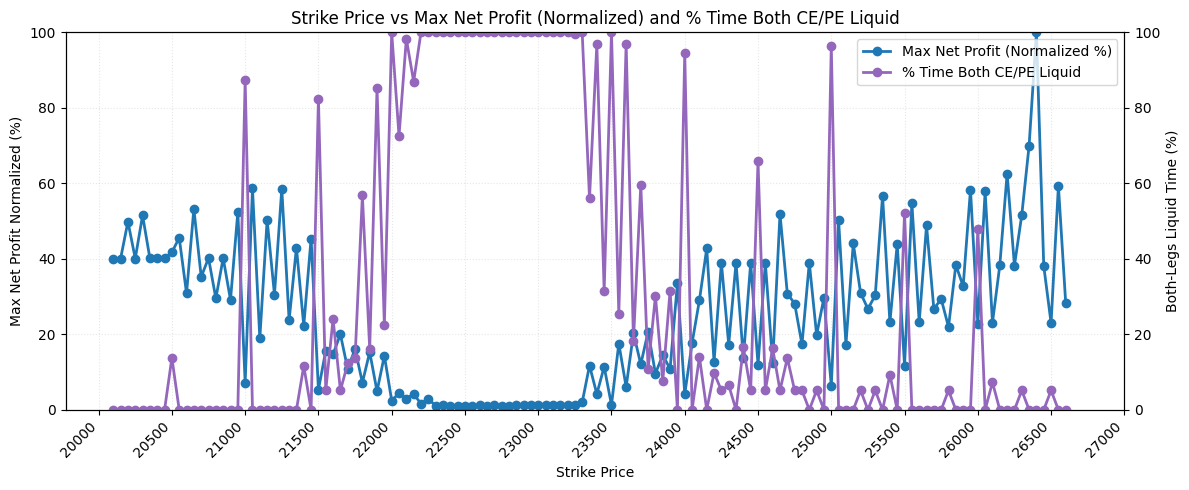

,strike_price,max_profit,max_profit_norm_pct,both_liquid_pct
0,20100,250.894717,40.071670,0.0
1,20150,250.883592,40.069893,0.0
2,20200,312.019560,49.834229,0.0
3,20250,250.961267,40.082299,0.0
4,20300,322.455238,51.500964,0.0


In [4]:
utils.plot_strike_vs_max_arbitrage_and_liquidity_pct(df, trading_cost=True).head()

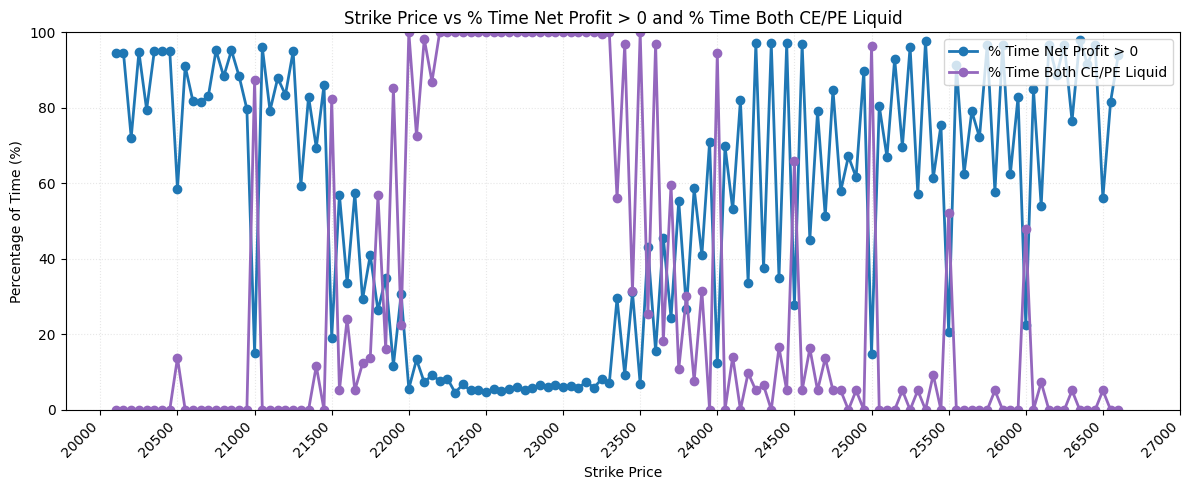

,strike_price,arbitrage_positive_pct,both_liquid_pct
0,20100,94.507846,0.0
1,20150,94.507846,0.0
2,20200,72.111270,0.0
3,20250,94.793153,0.0
4,20300,79.529244,0.0


In [5]:
utils.plot_strike_vs_arbitrage_positive_and_liquidity_pct(df, trading_cost=True).head()

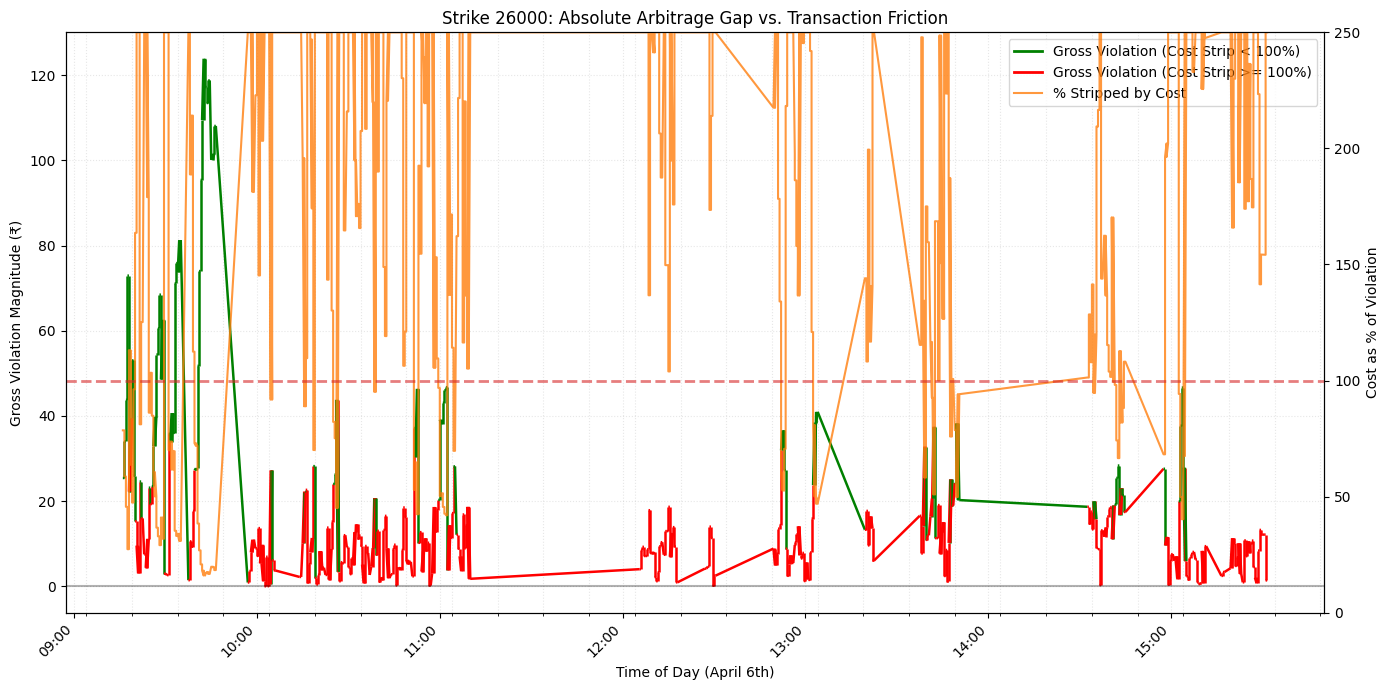

,fetch_time,abs_violation,cost,cost_stripped_pct
118,2026-04-06 09:16:00,25.426388,19.968114,78.533032
2083,2026-04-06 09:16:30,25.427872,19.966473,78.521999
2214,2026-04-06 09:16:30,34.027872,19.960633,58.659656
4048,2026-04-06 09:17:00,34.029356,19.958992,58.652278
4310,2026-04-06 09:17:00,43.779356,19.952537,45.575219
...,...,...,...,...
1453039,2026-04-06 15:30:30,12.137829,18.716110,154.196516
1454873,2026-04-06 15:31:00,12.139313,18.714466,154.164124
1455004,2026-04-06 15:31:00,1.389313,18.721484,1347.535058
1456838,2026-04-06 15:31:30,1.390797,18.719840,1345.979073


In [6]:
utils.plot_strike_abs_violation_vs_cost_stripped_pct(df[df['both_legs_liquid'] == True], strike=26000)

In [7]:
importlib.reload(utils)

<module 'utils' from 'd:\\finmod\\Nifty50-PutCallParity-Arbitrage\\utils.py'>

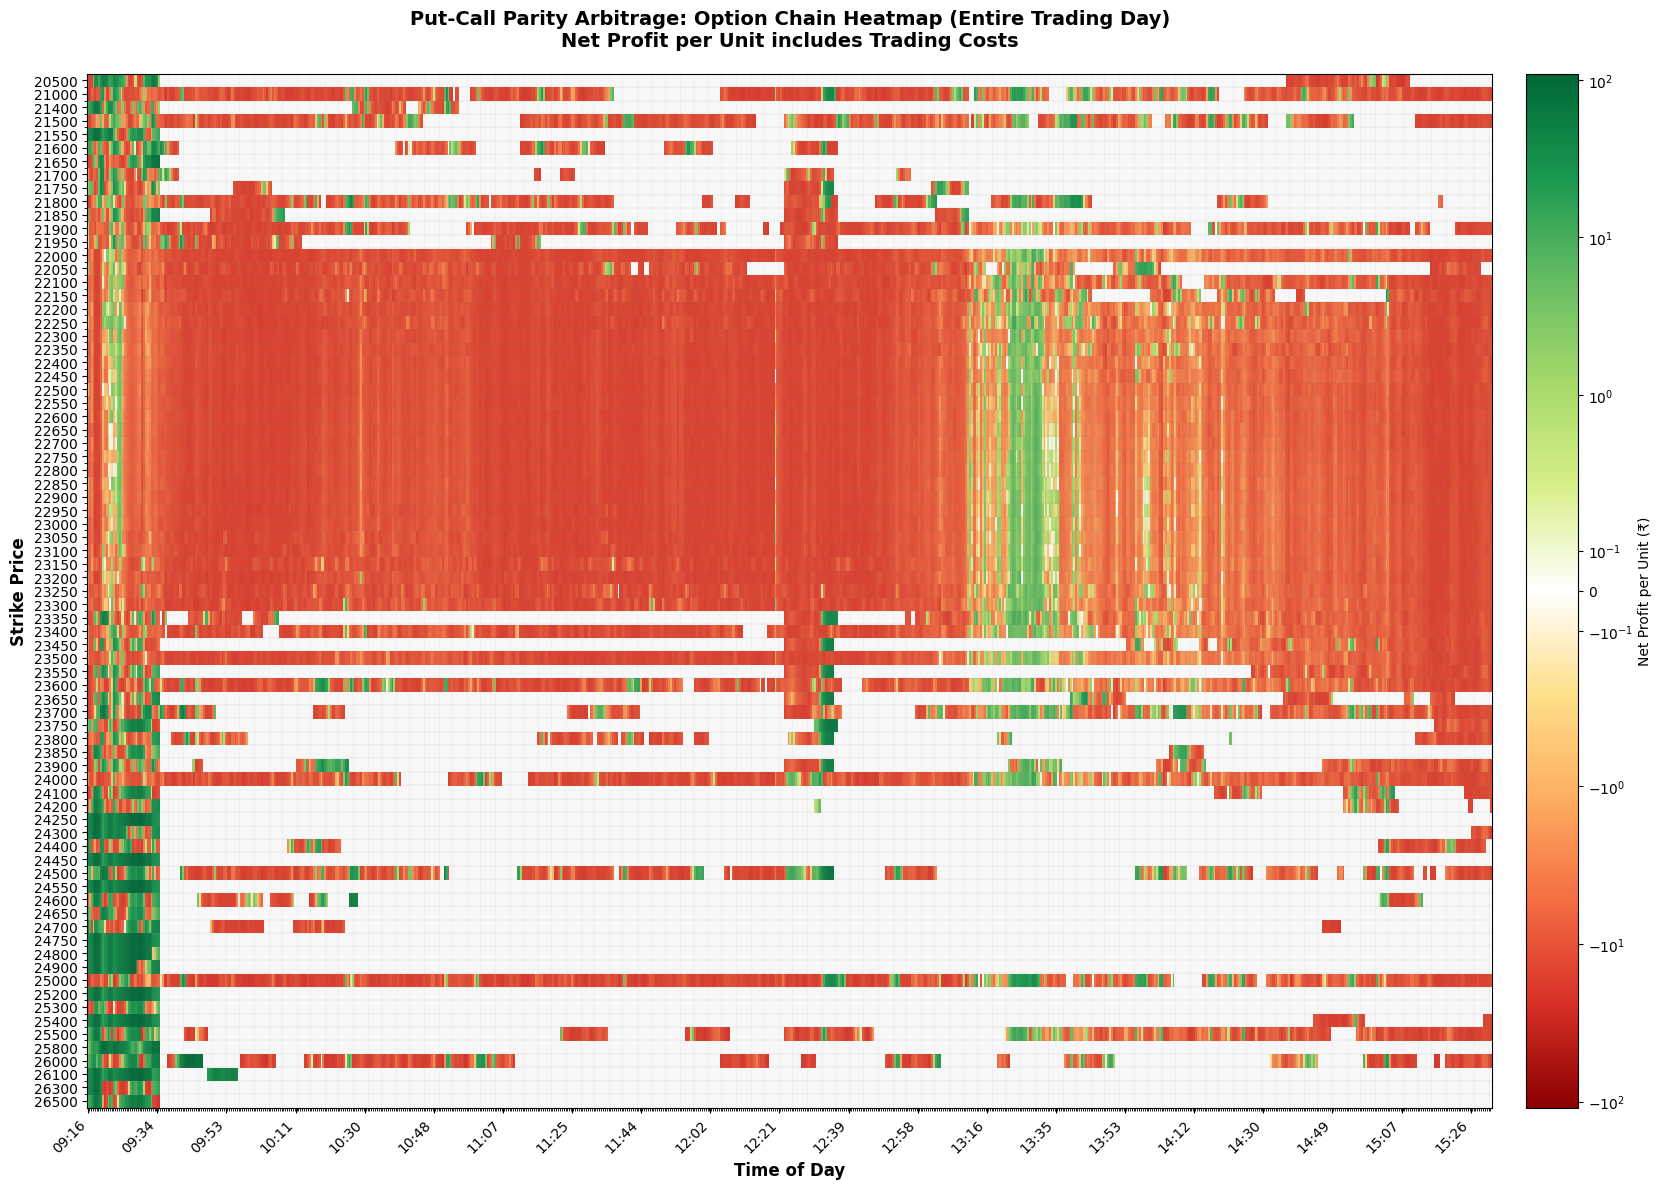

In [8]:
# COMPREHENSIVE HEATMAP: Entire Option Chain Over Entire Trading Day
# X-axis: Time of Day (09:15 to 15:30)
# Y-axis: Strike Prices (sorted)
# Color: Net Profit (Green=Profitable, Red=Loss, White=Break-even)

pivot_data = utils.plot_option_chain_heatmap_over_time(
    df[df['both_legs_liquid'] == True],  # Filter for options that were liquid at least 50% of the time
    min_liquidity=0,  # Include all data (change to e.g., 500 for more liquid options)
    trading_cost=True,
    figsize=(18, 12),
    efficiency_band_pct=0.001,  # Smaller neutral band for faster color transition
)

In [9]:
df.columns

Index(['fetch_time', 'symbol', 'expiry', 'spot_price', 'strike_price',
       'ce_growwContractId', 'ce_displayName', 'ce_longDisplayName',
       'ce_token', 'ce_marketLot', 'ce_liveData_close', 'ce_liveData_ltp',
       'ce_liveData_dayChange', 'ce_liveData_dayChangePerc', 'ce_liveData_oi',
       'ce_liveData_prevOI', 'ce_greeks_delta', 'ce_greeks_gamma',
       'ce_greeks_theta', 'ce_greeks_vega', 'ce_greeks_rho', 'ce_greeks_iv',
       'ce_greeks_pop', 'ce_markers', 'pe_growwContractId', 'pe_displayName',
       'pe_longDisplayName', 'pe_token', 'pe_marketLot', 'pe_liveData_close',
       'pe_liveData_ltp', 'pe_liveData_dayChange', 'pe_liveData_dayChangePerc',
       'pe_liveData_oi', 'pe_liveData_prevOI', 'pe_greeks_delta',
       'pe_greeks_gamma', 'pe_greeks_theta', 'pe_greeks_vega', 'pe_greeks_rho',
       'pe_greeks_iv', 'pe_greeks_pop', 'pe_markers', 'T', 'liquidity',
       'both_legs_liquid', 'both_legs_liquid_time_pct', 'market_side',
       'theoretical_side', 'violation

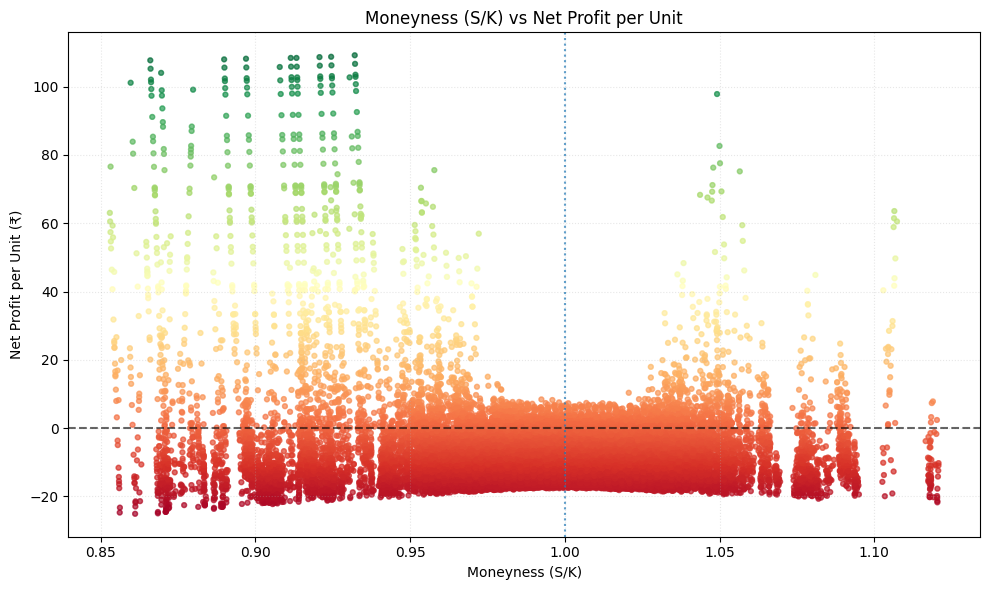

,moneyness,net_profit_per_unit
8,1.106227,-12.679548
18,1.079888,-19.907696
26,1.059703,10.244617
28,1.054774,-12.523322
29,1.052327,33.991140


In [10]:
# SCATTER: Moneyness (S/K) vs Net Profit per Unit
moneyness_df = utils.plot_moneyness_vs_net_profit(
    df[df['both_legs_liquid'] == True],  # Filter for options that were liquid at least 50% of the tim
    min_liquidity=0,
)
moneyness_df.head()

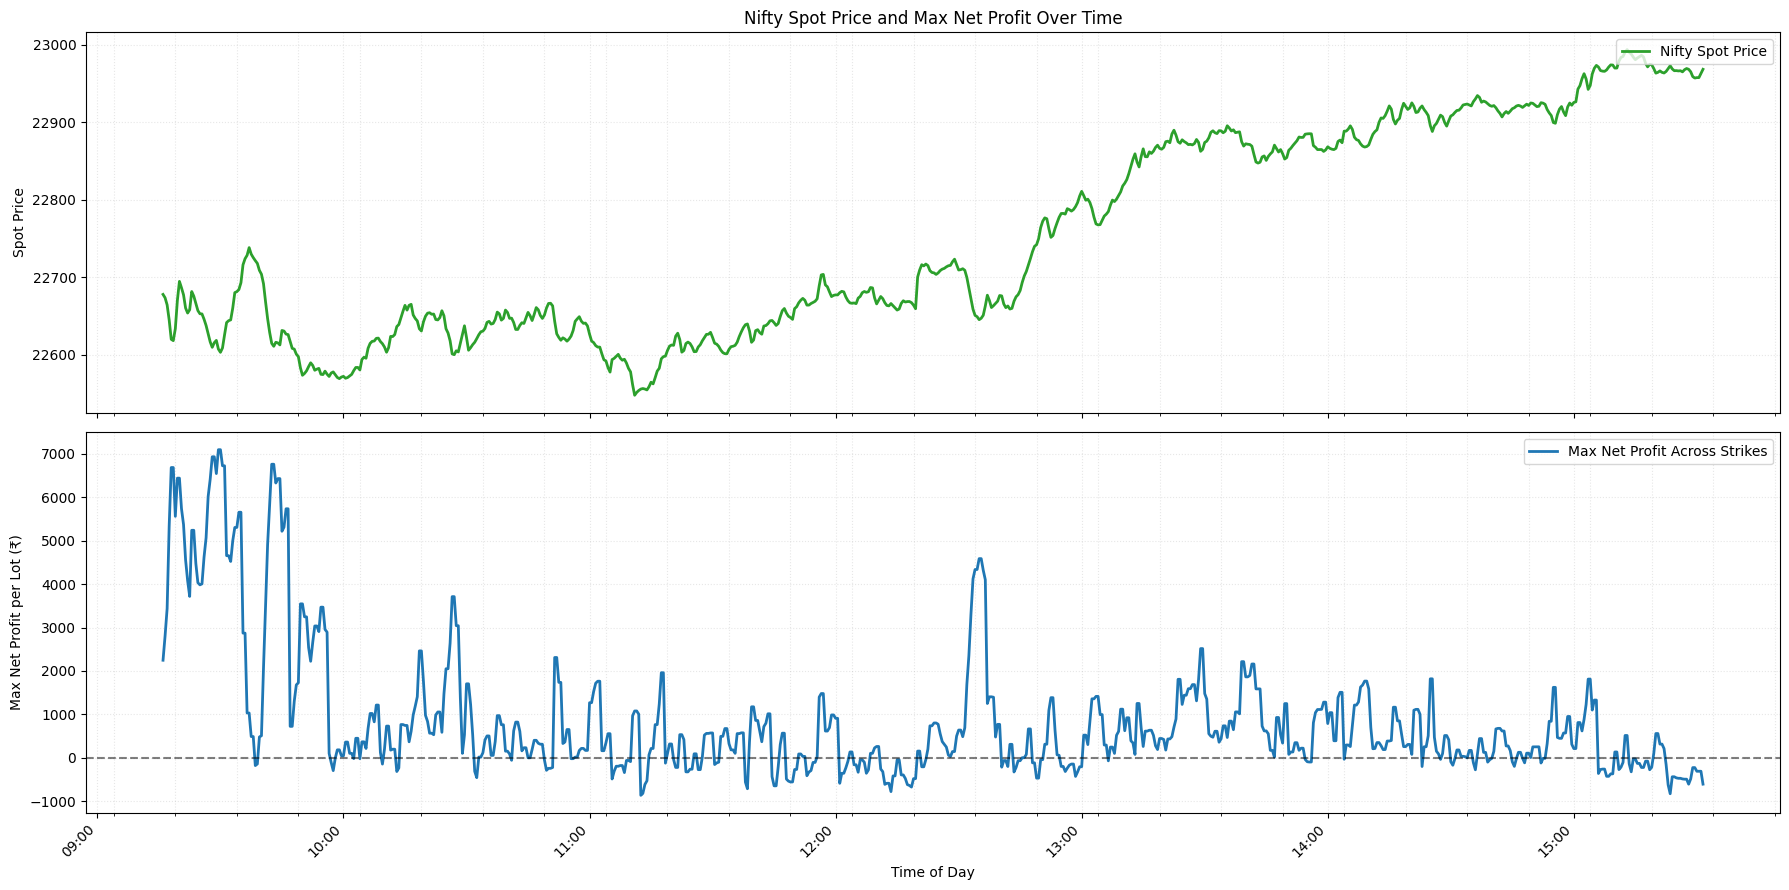

,fetch_time,spot_price,max_profit
0,2026-04-06 09:16:00,22677.650,2246.874183
1,2026-04-06 09:16:30,22673.325,2806.444453
2,2026-04-06 09:17:00,22664.125,3437.562047
3,2026-04-06 09:17:30,22644.675,5336.999690
4,2026-04-06 09:18:00,22619.725,6686.833204


In [11]:
# TWO-PANEL VIEW: Spot Price (Top) and Max Net Profit Across Strikes (Bottom)
spot_profit_df = utils.plot_spot_and_max_profit_over_time(
    df[df['both_legs_liquid'] == True],
    min_liquidity=0,
    trading_cost=True,
    per_lot=True,
    figsize=(18, 9),
)
spot_profit_df.head()

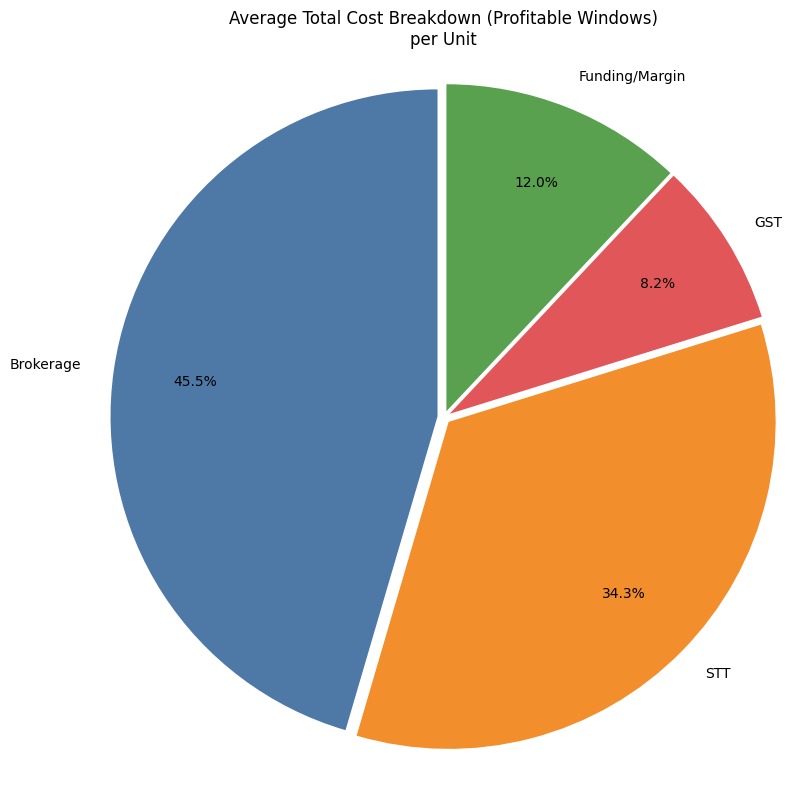

,avg_cost_per_unit
Brokerage,8.334032
STT,6.296012
GST,1.500126
Funding/Margin,2.202392
Total,18.332561


In [12]:
# COST BREAKDOWN PIE: Average total_cost in profitable windows
cost_breakdown = utils.plot_avg_cost_breakdown_pie(
    df[df['both_legs_liquid'] == True],
    profitable_only=True,
    min_liquidity=0,
    per_lot=False,
)
cost_breakdown

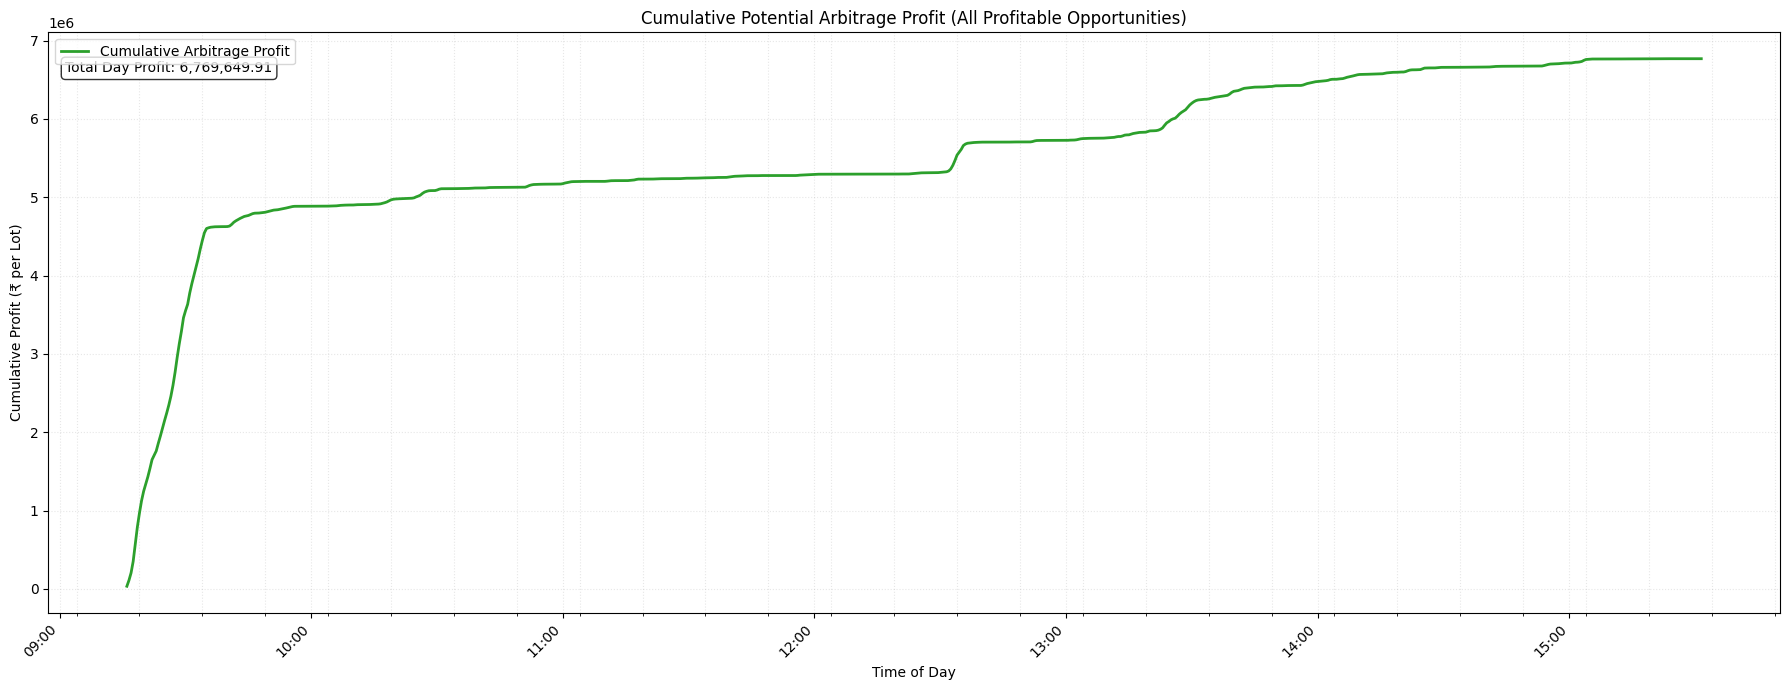

,fetch_time,interval_profit,opportunities_count,cumulative_profit
747,2026-04-06 15:29:30,0.0,0,6.769650e+06
748,2026-04-06 15:30:00,0.0,0,6.769650e+06
749,2026-04-06 15:30:30,0.0,0,6.769650e+06
750,2026-04-06 15:31:00,0.0,0,6.769650e+06
751,2026-04-06 15:31:30,0.0,0,6.769650e+06


In [13]:
# CUMSUM ARBITRAGE PROFIT: 1 lot at every profitable opportunity across strikes
cumsum_profit_df = utils.plot_cumsum_arbitrage_profit_all_opportunities(
     df,
    require_liquid=True,
    min_liquidity=0,
    per_lot=True,
    figsize=(18, 7),
)
cumsum_profit_df.tail()

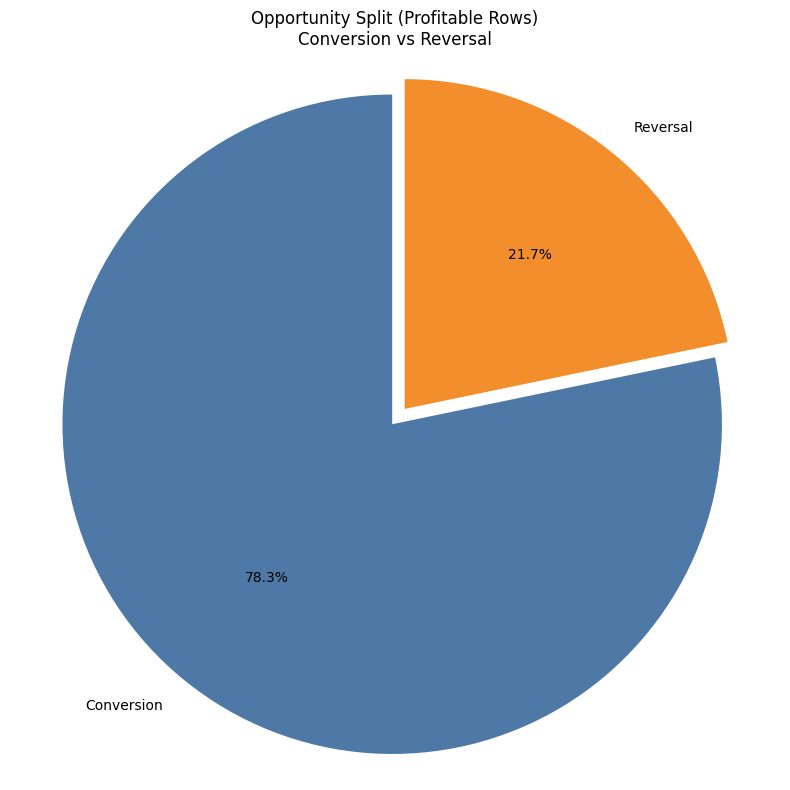

,profitable_count
Conversion,5588.0
Reversal,1553.0
Total,7141.0


In [14]:
# OPPORTUNITY SPLIT (Pie): Conversion vs Reversal for profitable rows
opportunity_split = utils.plot_opportunity_split_pie(
    df[df['both_legs_liquid'] == True],
    min_liquidity=0,
    require_liquid=False,
)
opportunity_split

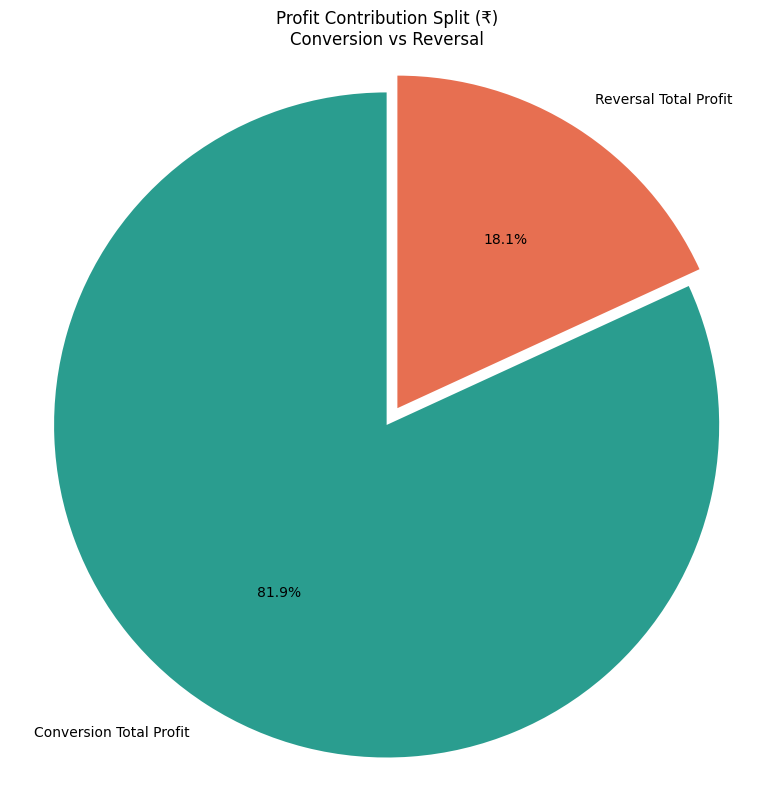

,total_profit_rupees
Conversion Total Profit,5.541731e+06
Reversal Total Profit,1.227919e+06
Total,6.769650e+06


In [15]:
# PROFIT CONTRIBUTION SPLIT (Pie): Conversion vs Reversal by total rupees
profit_contribution_split = utils.plot_profit_contribution_split_pie(
    df[df['both_legs_liquid'] == True],
    min_liquidity=0,
    require_liquid=False,
)
profit_contribution_split

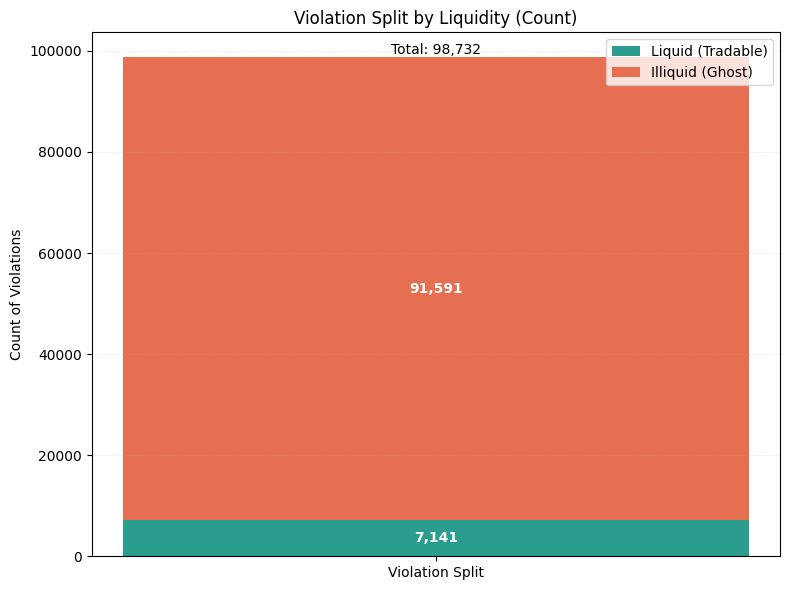

,Liquid (Tradable),Illiquid (Ghost),Total
Violation Split,7141,91591,98732


In [19]:
# STACKED BAR: Liquid (Tradable) vs Illiquid (Ghost)
violation_split_bar = utils.plot_violation_liquidity_stacked_bar(
    df,
    measure='count',
    profitable_only=True,
    min_liquidity=0,
    require_liquid=False,
)
violation_split_bar

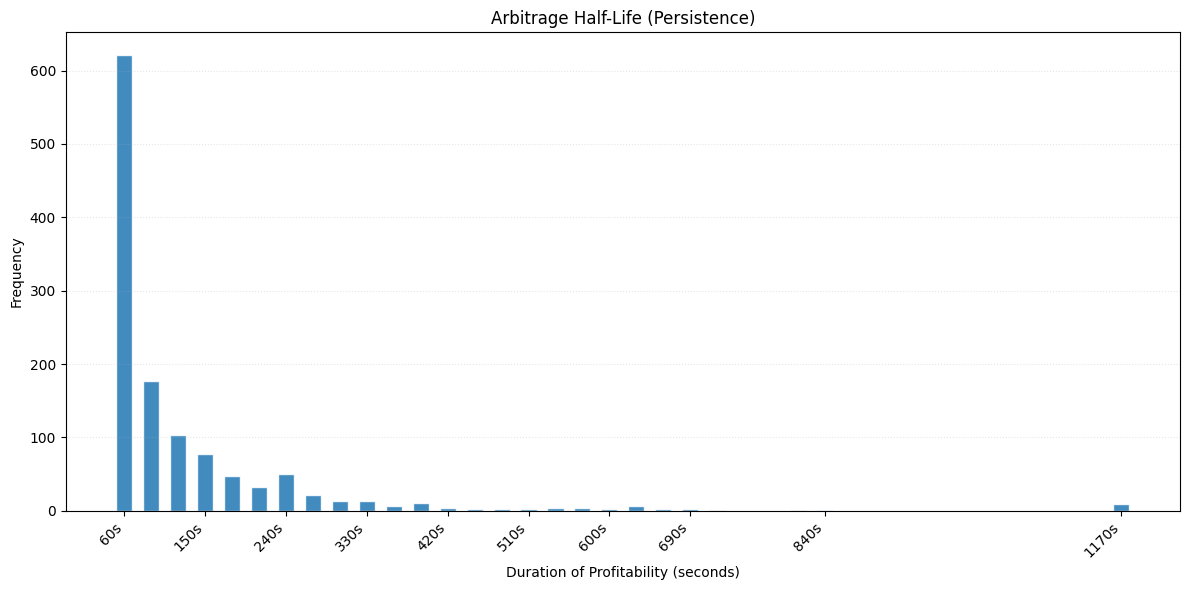

,duration_seconds,duration_intervals,frequency
0,60,2,621
1,90,3,177
2,120,4,104
3,150,5,77
4,180,6,47


In [26]:
import importlib
importlib.reload(utils)

# ARBITRAGE HALF-LIFE (Persistence): Consecutive profitable 30-second intervals
half_life_df = utils.plot_arbitrage_half_life_histogram(
    df[df['both_legs_liquid'] == True],
    min_liquidity=0,
    require_liquid=False,
    per_lot=True,
    figsize=(12, 6),
)
half_life_df.head()

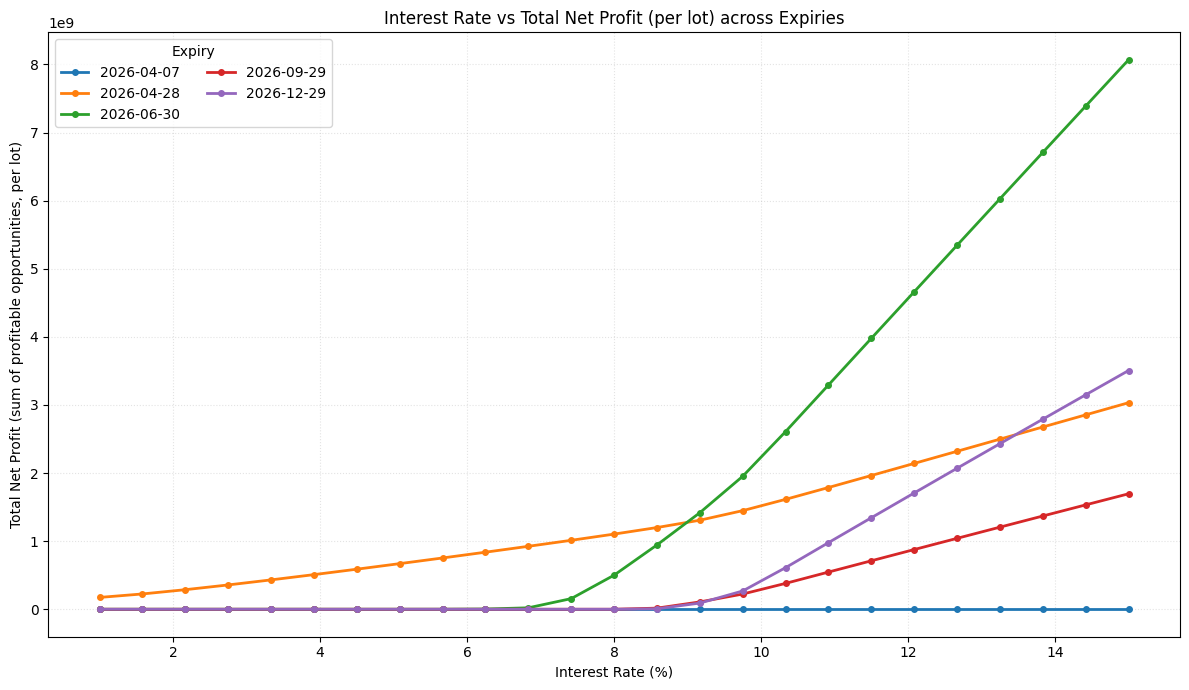

,expiry,obs_date,interest_rate,interest_rate_pct,total_net_profit_per_lot
0,2026-04-07,2026-04-07,0.010000,1.000000,0.0
1,2026-04-07,2026-04-07,0.015833,1.583333,0.0
2,2026-04-07,2026-04-07,0.021667,2.166667,0.0
3,2026-04-07,2026-04-07,0.027500,2.750000,0.0
4,2026-04-07,2026-04-07,0.033333,3.333333,0.0


In [29]:
from pathlib import Path
import re
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import config
import utils

importlib.reload(utils)

# INTEREST RATE vs NET PROFIT (5 expiries on one plot)
base_dir = Path('data')
full_files = sorted(base_dir.glob('*/option_chain_nifty_*_full_history.csv'))

expiry_to_file = {}
pattern = re.compile(r'option_chain_nifty_(\d{4}-\d{2}-\d{2})_full_history\.csv')
for file_path in full_files:
    match = pattern.match(file_path.name)
    if not match:
        continue
    expiry_str = match.group(1)
    obs_date = file_path.parent.name

    # Keep the latest available observation file for each expiry.
    if expiry_str not in expiry_to_file or obs_date > expiry_to_file[expiry_str][0]:
        expiry_to_file[expiry_str] = (obs_date, file_path)

selected_expiries = sorted(expiry_to_file.keys())[:5]

if len(selected_expiries) < 5:
    print(f"Only {len(selected_expiries)} unique expiries found; plotting available ones.")

rate_grid = np.linspace(0.01, 0.15, 25)  # annualized rate from 1% to 15%
original_rl = config.rl

interest_vs_profit_rows = []

try:
    for expiry_str in selected_expiries:
        obs_date, file_path = expiry_to_file[expiry_str]
        base_df = utils.load_and_clean_data(str(file_path))

        for r in rate_grid:
            config.rl = float(r)
            temp = utils.identify_arbitrage(base_df.copy())
            temp = utils.apply_costs(temp)

            total_net_profit_per_lot = float(
                temp.loc[temp['net_profit_per_unit'] > 0, 'net_profit_per_lot'].sum()
            )

            interest_vs_profit_rows.append({
                'expiry': expiry_str,
                'obs_date': obs_date,
                'interest_rate': float(r),
                'interest_rate_pct': float(r * 100.0),
                'total_net_profit_per_lot': total_net_profit_per_lot,
            })
finally:
    config.rl = original_rl

interest_rate_profit_df = pd.DataFrame(interest_vs_profit_rows)

plt.figure(figsize=(12, 7))
for expiry_str, group in interest_rate_profit_df.groupby('expiry'):
    g = group.sort_values('interest_rate')
    plt.plot(
        g['interest_rate_pct'],
        g['total_net_profit_per_lot'],
        marker='o',
        linewidth=2,
        markersize=4,
        label=expiry_str,
    )

plt.title('Interest Rate vs Total Net Profit (per lot) across Expiries')
plt.xlabel('Interest Rate (%)')
plt.ylabel('Total Net Profit (sum of profitable opportunities, per lot)')
plt.grid(True, linestyle=':', alpha=0.35)
plt.legend(title='Expiry', ncol=2)
plt.tight_layout()
plt.show()

interest_rate_profit_df.head()